In [12]:
from core.data_reader import average_precipitation_germany, daily_average_germany, monthly_average_germany, monthly_total_germany, yearly_raps_yield, print_metadata, total_precipitation, yearly_potato_yield
import os
from matplotlib import pyplot as plt
import tqdm
import numpy as np

['pr_hyras_1_1950_v6-1_de.nc', 'pr_hyras_1_1951_v6-1_de.nc', 'pr_hyras_1_1952_v6-1_de.nc', 'pr_hyras_1_1953_v6-1_de.nc', 'pr_hyras_1_1954_v6-1_de.nc', 'pr_hyras_1_1955_v6-1_de.nc', 'pr_hyras_1_1956_v6-1_de.nc', 'pr_hyras_1_1957_v6-1_de.nc', 'pr_hyras_1_1958_v6-1_de.nc', 'pr_hyras_1_1959_v6-1_de.nc', 'pr_hyras_1_1960_v6-1_de.nc', 'pr_hyras_1_1961_v6-1_de.nc', 'pr_hyras_1_1962_v6-1_de.nc', 'pr_hyras_1_1963_v6-1_de.nc', 'pr_hyras_1_1964_v6-1_de.nc', 'pr_hyras_1_1965_v6-1_de.nc', 'pr_hyras_1_1966_v6-1_de.nc', 'pr_hyras_1_1967_v6-1_de.nc', 'pr_hyras_1_1968_v6-1_de.nc', 'pr_hyras_1_1969_v6-1_de.nc', 'pr_hyras_1_1970_v6-1_de.nc', 'pr_hyras_1_1971_v6-1_de.nc', 'pr_hyras_1_1972_v6-1_de.nc', 'pr_hyras_1_1973_v6-1_de.nc', 'pr_hyras_1_1974_v6-1_de.nc', 'pr_hyras_1_1975_v6-1_de.nc', 'pr_hyras_1_1976_v6-1_de.nc', 'pr_hyras_1_1977_v6-1_de.nc', 'pr_hyras_1_1978_v6-1_de.nc', 'pr_hyras_1_1979_v6-1_de.nc', 'pr_hyras_1_1980_v6-1_de.nc', 'pr_hyras_1_1981_v6-1_de.nc', 'pr_hyras_1_1982_v6-1_de.nc', 'pr_hyras

Processing files: 100%|██████████| 76/76 [03:20<00:00,  2.64s/it]


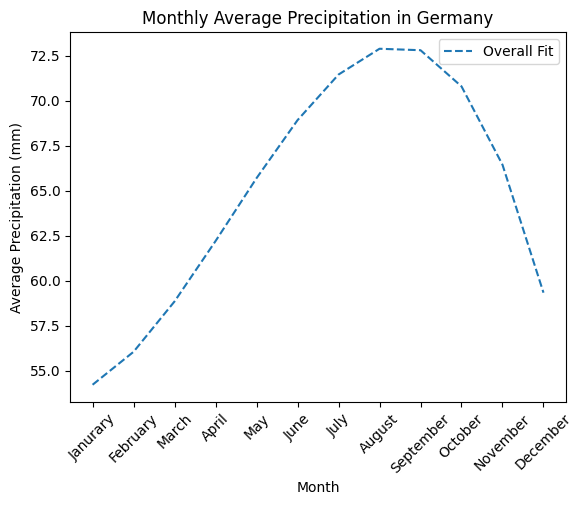

In [13]:
files = []
counter = 0


for file in os.listdir('.data'):
    if file.endswith('.nc'):
        if counter > 100:
            break
        files.append(file)

        counter += 1

files_sorted = sorted(files, key=lambda x: x.split('_')[3])
print(files_sorted)

months = ["Janurary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

nc_files = [f for f in files_sorted if f.endswith('.nc')]

results = []
for file in tqdm.tqdm(nc_files, desc="Processing files"):
    filename = os.path.join('.data', file)
    avg_precip = monthly_total_germany(filename)
    results.append((file.split('_')[3], avg_precip[1]))

#for label, data in results:
    #plt.plot(months, data, label=label)

overall_monthly_average_totals = [(month_name, 0) for month_name in months]

for i, r in enumerate(results):
    for j, month in enumerate(r[1]):
        overall_monthly_average_totals[j] = (overall_monthly_average_totals[j][0], overall_monthly_average_totals[j][1] + month)
overall_precipitation = [x[1] / len(results) for x in overall_monthly_average_totals]

fit_curve = np.polyfit(range(len(months)), overall_precipitation, 3)
fit_func = np.poly1d(fit_curve)
plt.plot(months, fit_func(range(len(months))), label='Overall Fit', linestyle='--')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.title('Monthly Average Precipitation in Germany')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Processing files: 100%|██████████| 76/76 [03:05<00:00,  2.44s/it]


[('1950', 296450016.0), ('1951', 270252256.0), ('1952', 294652640.0), ('1953', 211733104.0), ('1954', 312870592.0), ('1955', 280030144.0), ('1956', 300187808.0), ('1957', 281312416.0), ('1958', 311798912.0), ('1959', 196027776.0), ('1960', 303738688.0), ('1961', 308948736.0), ('1962', 249253184.0), ('1963', 235832944.0), ('1964', 227275552.0), ('1965', 353459680.0), ('1966', 345959392.0), ('1967', 297165440.0), ('1968', 300515776.0), ('1969', 258027296.0), ('1970', 325690912.0), ('1971', 214706752.0), ('1972', 235815728.0), ('1973', 250871600.0), ('1974', 315925920.0), ('1975', 235369632.0), ('1976', 211165456.0), ('1977', 294277056.0), ('1978', 286194752.0), ('1979', 294921728.0), ('1980', 299574752.0), ('1981', 354729984.0), ('1982', 251264224.0), ('1983', 280155072.0), ('1984', 294419200.0), ('1985', 261826416.0), ('1986', 308470144.0), ('1987', 315366080.0), ('1988', 310615744.0), ('1989', 245146816.0), ('1990', 282413952.0), ('1991', 229648928.0), ('1992', 283174976.0), ('1993', 3

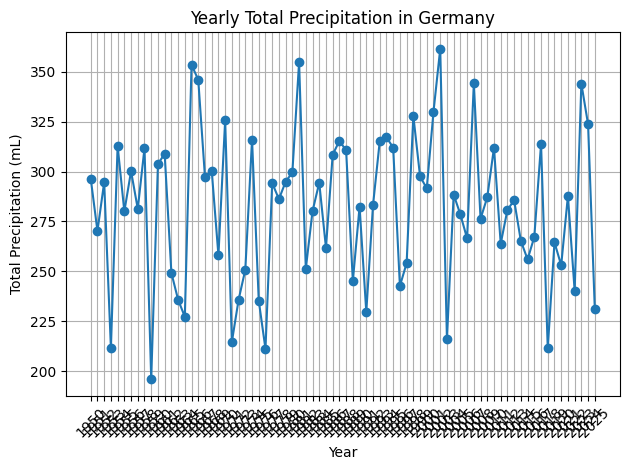

In [14]:
yearly_precipitation = []
for file in tqdm.tqdm(files_sorted, desc="Processing files"):
    filename = os.path.join('.data', file)
    yearly_precipitation.append((file.split('_')[3], total_precipitation(filename)))

print(yearly_precipitation)

plt.plot([x[0] for x in yearly_precipitation], [x[1]/1_000_000 for x in yearly_precipitation], marker='o')
plt.xlabel('Year')
plt.ylabel('Total Precipitation (mL)')
plt.title('Yearly Total Precipitation in Germany')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

Year: 1951, Potato Yield: 24330307.0 tons
Year: 1952, Potato Yield: 24069653.0 tons
Year: 1953, Potato Yield: 24786716.0 tons
Year: 1954, Potato Yield: 27066702.0 tons
Year: 1955, Potato Yield: 23094119.0 tons
Year: 1956, Potato Yield: 27013722.0 tons
Year: 1957, Potato Yield: 26501510.0 tons
Year: 1958, Potato Yield: 22868412.0 tons
Year: 1959, Potato Yield: 22719950.0 tons
Year: 1960, Potato Yield: 24558918.0 tons
Year: 1961, Potato Yield: 21515630.0 tons
Year: 1962, Potato Yield: 25103600.0 tons
Year: 1963, Potato Yield: 25812413.0 tons
Year: 1964, Potato Yield: 20623985.0 tons
Year: 1965, Potato Yield: 18094631.0 tons
Year: 1966, Potato Yield: 18839385.0 tons
Year: 1967, Potato Yield: 21293532.0 tons
Year: 1968, Potato Yield: 19195690.0 tons
Year: 1969, Potato Yield: 15984598.0 tons
Year: 1970, Potato Yield: 16250042.0 tons
Year: 1971, Potato Yield: 15176069.0 tons
Year: 1972, Potato Yield: 15038212.0 tons
Year: 1973, Potato Yield: 13676482.0 tons
Year: 1974, Potato Yield: 14548488

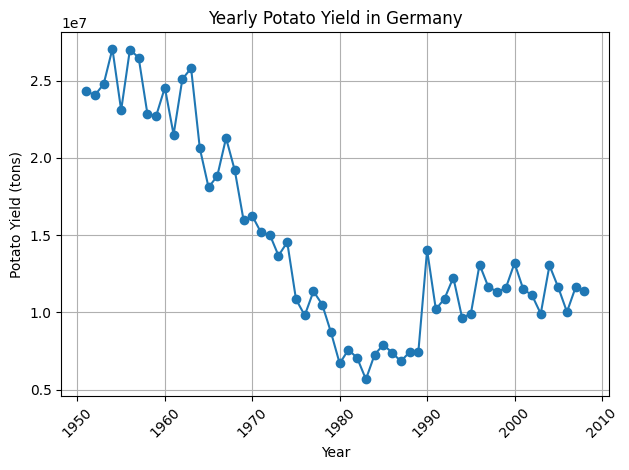

In [15]:
for i in range(1951, 2009):
    potato_yield = yearly_potato_yield('.data/41241-0002_de_flat.csv', i)
    print(f"Year: {i}, Potato Yield: {potato_yield} tons")

plt.plot(range(1951, 2009), [yearly_potato_yield('.data/41241-0002_de_flat.csv', i) for i in range(1951, 2009)], marker='o')
plt.xlabel('Year')
plt.ylabel('Potato Yield (tons)')
plt.title('Yearly Potato Yield in Germany')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

58
58


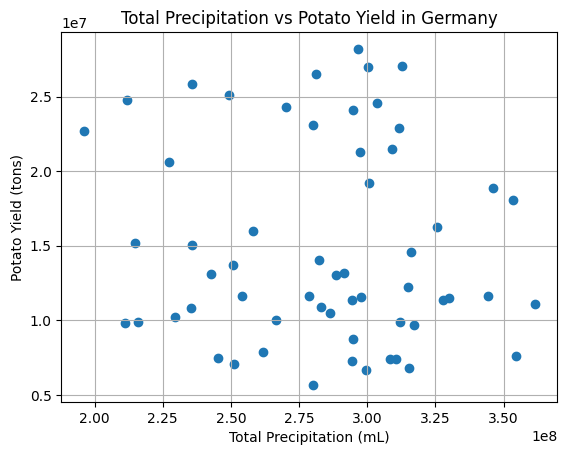

In [16]:
print(len(yearly_precipitation[:58]))
print(len([yearly_potato_yield('.data/41241-0002_de_flat.csv', i) for i in range(1951, 2009)]))

plot_tuple_list = []

for i in yearly_precipitation[:58]:
    if yearly_potato_yield('.data/41241-0002_de_flat.csv', int(i[0])) is not None:
        plot_tuple_list.append((i[1], yearly_potato_yield('.data/41241-0002_de_flat.csv', int(i[0]))))

plt.scatter([x[0] for x in plot_tuple_list], [x[1] for x in plot_tuple_list])
plt.xlabel('Total Precipitation (mL)')
plt.ylabel('Potato Yield (tons)')
plt.title('Total Precipitation vs Potato Yield in Germany')
plt.grid()
plt.show()

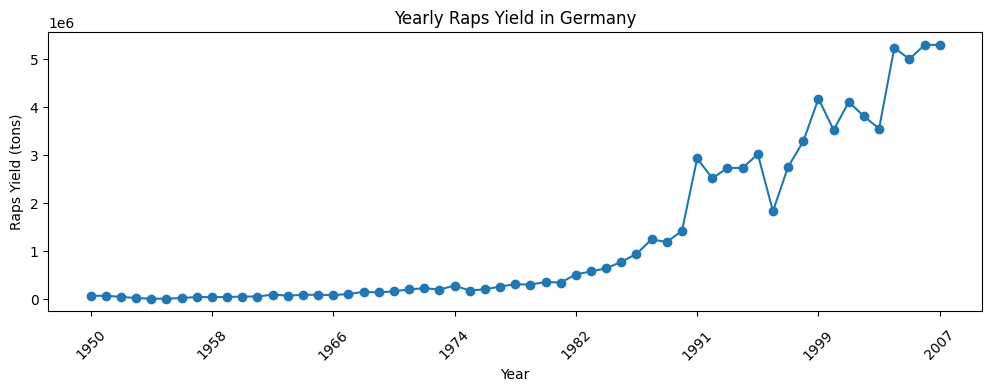

In [17]:
#print(len(yearly_precipitation[:58]))
#print(len([yearly_raps_yield('.data/41241-0002_de_flat.csv', i) for i in range(1951, 2009)]))

raps_plot_tuple_list = []
for i in yearly_precipitation[:58]:
    try:
        if yearly_raps_yield('.data/41241-0002_de_flat.csv', int(i[0])) is not None:
                raps_plot_tuple_list.append((i[0], yearly_raps_yield('.data/41241-0002_de_flat.csv', int(i[0]))))
    except (ValueError, TypeError):
        pass

import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot([x[0] for x in raps_plot_tuple_list], [x[1] for x in raps_plot_tuple_list], marker='o')

ax.set_title('Yearly Raps Yield in Germany')
ax.set_xlabel('Year')
ax.set_ylabel('Raps Yield (tons)')

# choose a reasonable number of ticks
ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=10))

# rotate labels and add padding in pixels
ax.tick_params(axis='x', rotation=45, pad=8)

fig.tight_layout(pad=1.0)
plt.show()